In [31]:
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy.stats import chi2_contingency, kurtosis, skew, ttest_ind
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [32]:
data_path = '../data/raw/DiamondsPrices.csv'
df=pd.read_csv(data_path, index_col=0)

print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (53943, 10)


,carat,cut,color,clarity,depth,table,price,x,y,z
1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


In [33]:
df.describe()

,carat,depth,table,price,x,y,z
count,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000
mean,0.797935,61.749322,57.457251,3932.734294,5.731158,5.734526,3.538730
std,0.473999,1.432626,2.234549,3989.338447,1.121730,1.142103,0.705679
min,0.200000,43.000000,43.000000,326.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,950.000000,4.710000,4.720000,2.910000
50%,0.700000,61.800000,57.000000,2401.000000,5.700000,5.710000,3.530000
75%,1.040000,62.500000,59.000000,5324.000000,6.540000,6.540000,4.040000
max,5.010000,79.000000,95.000000,18823.000000,10.740000,58.900000,31.800000


In [34]:
def summary_profiling_table(df: pd.DataFrame) -> pd.DataFrame:
    summary = []
    for col in df.columns:
        series = df[col]
        summary.append({
            "variable": col,
            "num_of_values": series.notna().sum(),
            "pct_missing": series.isna().mean() * 100,
            "unique_values": series.nunique(dropna=True),
            "mean": series.mean() if pd.api.types.is_numeric_dtype(series) else np.nan,
            "python_type": str(series.dtype),
            "inferred_type": pd.api.types.infer_dtype(series, skipna=True)
        })
    return (
        pd.DataFrame(summary)
        .sort_values(by=["pct_missing", "unique_values"], ascending=[False, False])
        .reset_index(drop=True)
    )

summary_profiling_table(df)

,variable,num_of_values,pct_missing,unique_values,mean,python_type,inferred_type
0,price,53943,0.0,11602,3932.734294,int64,integer
1,x,53943,0.0,554,5.731158,float64,floating
2,y,53943,0.0,552,5.734526,float64,floating
3,z,53943,0.0,375,3.538730,float64,floating
4,carat,53943,0.0,273,0.797935,float64,floating
5,depth,53943,0.0,184,61.749322,float64,floating
6,table,53943,0.0,127,57.457251,float64,floating
7,clarity,53943,0.0,8,NaN,str,string
8,color,53943,0.0,7,NaN,str,string
9,cut,53943,0.0,5,NaN,str,string


In [35]:
def criar_dicionario_dados(df):
    descricoes = {
        "carat": "Peso do diamante em quilates.",
        "cut": "Qualidade do corte do diamante.",
        "color": "Classificação da cor do diamante (D = melhor, J = pior).",
        "clarity": "Grau de pureza do diamante.",
        "depth": "Profundidade total do diamante em percentagem.",
        "table": "Largura da mesa do diamante em percentagem.",
        "price": "Preço do diamante em dólares americanos.",
        "x": "Comprimento do diamante em milímetros.",
        "y": "Largura do diamante em milímetros.",
        "z": "Profundidade do diamante em milímetros."
    }

    tabela = pd.DataFrame({
        "Variável": df.columns,
        "Tipo de Dados": [str(df[col].dtype) for col in df.columns],
        "Descrição": [descricoes.get(col, "Descrição não disponível.") for col in df.columns]
    })

    return tabela

In [36]:
dicionario = criar_dicionario_dados(df)
dicionario


,Variável,Tipo de Dados,Descrição
0,carat,float64,Peso do diamante em quilates.
1,cut,str,Qualidade do corte do diamante.
2,color,str,"Classificação da cor do diamante (D = melhor, ..."
3,clarity,str,Grau de pureza do diamante.
4,depth,float64,Profundidade total do diamante em percentagem.
5,table,float64,Largura da mesa do diamante em percentagem.
6,price,int64,Preço do diamante em dólares americanos.
7,x,float64,Comprimento do diamante em milímetros.
8,y,float64,Largura do diamante em milímetros.
9,z,float64,Profundidade do diamante em milímetros.


In [37]:
def numeric_quality_report(df):
    numeric_df = df.select_dtypes(include=[np.number])
    summary = []
    for col in numeric_df.columns:
        s = numeric_df[col].dropna()
        if len(s) == 0:
            continue
        mean_val = s.mean()
        median_val = s.median()
        std_val = s.std()
        q1 = s.quantile(0.25)
        q3 = s.quantile(0.75)
        cv = std_val / mean_val if abs(mean_val) > 1e-9 else np.nan
        summary.append({
            "variable": col,
            "n": len(s),
            "mean": mean_val,
            "median": median_val,
            "mean_minus_median": mean_val - median_val,
            "std": std_val,
            "cv": cv,
            "IQR": q3 - q1,
            "skewness": skew(s, bias=False),
            "kurtosis_excess": kurtosis(s, bias=False)
        })
    return (
        pd.DataFrame(summary)
        .sort_values("skewness", key=lambda x: abs(x), ascending=False)
        .reset_index(drop=True)
    )


In [38]:
numeric_report = numeric_quality_report(df)

In [39]:
def interpret_numeric_quality(df_report):
    report = df_report.copy()

    def mean_median_label(x, tol=1e-6):
        if pd.isna(x): return np.nan
        elif abs(x) < tol: return "Mean and median are approximately equal"
        elif x > 0: return "Mean greater than median (suggests positive skew)"
        else: return "Mean lower than median (suggests negative skew)"

    def cv_label(cv):
        if pd.isna(cv): return "CV undefined (mean ≈ 0)"
        elif cv < 0: return "CV negative (mean < 0)"
        elif cv < 0.3: return "Low variability"
        elif cv < 0.7: return "Moderate variability"
        else: return "High variability"

    def skew_label(sk):
        if pd.isna(sk): return np.nan
        abs_sk = abs(sk)
        magnitude = "Approximately symmetric" if abs_sk < 0.5 else ("Moderately skewed" if abs_sk < 1 else "Highly skewed")
        direction = " (positive/right skew)" if sk > 0 else (" (negative/left skew)" if sk < 0 else "")
        return magnitude + direction

    def kurt_label(k):
        if pd.isna(k): return np.nan
        elif k < -1.0: return "Very flat distribution (platykurtic)"
        elif k < -0.5: return "Light tails (mild platykurtic)"
        elif abs(k) <= 0.5: return "Approximately normal tails (mesokurtic)"
        elif k <= 1.0: return "Slightly heavy tails"
        elif k <= 3.0: return "Moderately heavy tails"
        else: return "Heavy tails / extreme values (leptokurtic)"

    report["Mean_vs_median_interpretation"] = report["mean_minus_median"].apply(mean_median_label)
    report["CV_interpretation"] = report["cv"].apply(cv_label)
    report["Skewness_interpretation"] = report["skewness"].apply(skew_label)
    report["Kurtosis_interpretation"] = report["kurtosis_excess"].apply(kurt_label)

    return report[[
        "variable", "n", "mean", "median", "mean_minus_median", "Mean_vs_median_interpretation",
        "std", "cv", "CV_interpretation", "IQR", "skewness", "Skewness_interpretation",
        "kurtosis_excess", "Kurtosis_interpretation"
    ]]



In [40]:
numeric_interpretive = interpret_numeric_quality(numeric_report)
numeric_interpretive

,variable,n,mean,median,mean_minus_median,Mean_vs_median_interpretation,std,cv,CV_interpretation,IQR,skewness,Skewness_interpretation,kurtosis_excess,Kurtosis_interpretation
0,y,53943,5.734526,5.71,0.024526,Mean greater than median (suggests positive skew),1.142103,0.199163,Low variability,1.82,2.434233,Highly skewed (positive/right skew),91.219791,Heavy tails / extreme values (leptokurtic)
1,price,53943,3932.734294,2401.00,1531.734294,Mean greater than median (suggests positive skew),3989.338447,1.014393,High variability,4374.00,1.618476,Highly skewed (positive/right skew),2.178040,Moderately heavy tails
2,z,53943,3.538730,3.53,0.008730,Mean greater than median (suggests positive skew),0.705679,0.199416,Low variability,1.13,1.522481,Highly skewed (positive/right skew),47.089370,Heavy tails / extreme values (leptokurtic)
3,carat,53943,0.797935,0.70,0.097935,Mean greater than median (suggests positive skew),0.473999,0.594032,Moderate variability,0.64,1.116705,Highly skewed (positive/right skew),1.256902,Moderately heavy tails
4,table,53943,57.457251,57.00,0.457251,Mean greater than median (suggests positive skew),2.234549,0.038891,Low variability,3.00,0.796836,Moderately skewed (positive/right skew),2.801180,Moderately heavy tails
5,x,53943,5.731158,5.70,0.031158,Mean greater than median (suggests positive skew),1.121730,0.195725,Low variability,1.83,0.378685,Approximately symmetric (positive/right skew),-0.618030,Light tails (mild platykurtic)
6,depth,53943,61.749322,61.80,-0.050678,Mean lower than median (suggests negative skew),1.432626,0.023201,Low variability,1.50,-0.082187,Approximately symmetric (negative/left skew),5.738874,Heavy tails / extreme values (leptokurtic)


In [41]:
def overall_data_quality_table(numeric_report):
    results = []
    for _, row in numeric_report.iterrows():
        cv = row["cv"]
        sk = row["skewness"]
        kurt = row["kurtosis_excess"]

        challenges = []
        if cv >= 0.7: challenges.append("High dispersion")
        if abs(sk) >= 1: challenges.append("Strong skewness")
        elif abs(sk) >= 0.5: challenges.append("Moderate skewness")
        if kurt >= 3: challenges.append("Heavy tails")
        elif kurt > 0.5: challenges.append("Moderately heavy tails")

        cv_flag   = False if pd.isna(cv) else (cv >= 0.7)
        sk_flag   = False if pd.isna(sk)   else (abs(sk) >= 1)
        kurt_flag = False if pd.isna(kurt) else (kurt >= 3)

        score = cv_flag + sk_flag + kurt_flag

        results.append({
            "variable": row["variable"],
            "validity_assessment": "Likely valid and meaningful feature",
            "modeling_assessment": ", ".join(challenges) if challenges else "Statistically well-behaved",
            "overall_quality": {
                0: "High Quality",
                1: "Moderate Quality",
                2: "Statistically Challenging",
                3: "Statistically Challenging"
            }.get(score, "Statistically Challenging")
        })
    return pd.DataFrame(results)


overall_data_quality_table(numeric_report)

,variable,validity_assessment,modeling_assessment,overall_quality
0,y,Likely valid and meaningful feature,"Strong skewness, Heavy tails",Statistically Challenging
1,price,Likely valid and meaningful feature,"High dispersion, Strong skewness, Moderately h...",Statistically Challenging
2,z,Likely valid and meaningful feature,"Strong skewness, Heavy tails",Statistically Challenging
3,carat,Likely valid and meaningful feature,"Strong skewness, Moderately heavy tails",Moderate Quality
4,table,Likely valid and meaningful feature,"Moderate skewness, Moderately heavy tails",High Quality
5,x,Likely valid and meaningful feature,Statistically well-behaved,High Quality
6,depth,Likely valid and meaningful feature,Heavy tails,Moderate Quality


In [42]:
def categorical_quality_report(df, rare_threshold=0.05):
    results = []

    for col in df.select_dtypes(exclude="number").columns:
        s = df[col]
        rel_freq = s.value_counts(normalize=True, dropna=True)

        cardinality = s.nunique(dropna=True)
        dominant_pct = rel_freq.max() * 100
        rare_levels = rel_freq[rel_freq < rare_threshold]

        score = 0
        if dominant_pct > 80:
            score += 1
        if len(rare_levels) > 3:
            score += 1
        if cardinality > 30:
            score += 1

        overall_quality = (
            "High Quality"              if score == 0 else
            "Moderate Quality"          if score == 1 else
            "Statistically Challenging"
        )

        results.append({
            "variable"         : col,
            "cardinality"      : cardinality,
            "cardinality_level": "Low" if cardinality < 10 else ("Moderate" if cardinality <= 30 else "High"),
            "dominant_pct"     : round(dominant_pct, 2),
            "rare_levels"      : len(rare_levels),
            "rare_pct"         : round(rare_levels.sum() * 100, 2),
            "imbalance"        : (
                "Balanced"           if dominant_pct < 60 else
                "Moderate imbalance" if dominant_pct < 80 else
                "High imbalance"
            ),
            "overall_quality"  : overall_quality
        })

    return pd.DataFrame(results)



In [43]:
categorical_report = categorical_quality_report(df)
categorical_report

,variable,cardinality,cardinality_level,dominant_pct,rare_levels,rare_pct,imbalance,overall_quality
0,cut,5,Low,39.95,1,2.98,Balanced,High Quality
1,color,7,Low,20.93,0,0.00,Balanced,High Quality
2,clarity,8,Low,24.22,2,4.69,Balanced,High Quality


In [44]:
corr_pearson = df.corr(numeric_only=True)
corr_target_pearson = corr_pearson['price'].sort_values(ascending=False)
corr_target_pearson

price    1.000000
carat    0.921591
x        0.884433
y        0.865419
z        0.861249
table    0.127118
depth   -0.010630
Name: price, dtype: float64

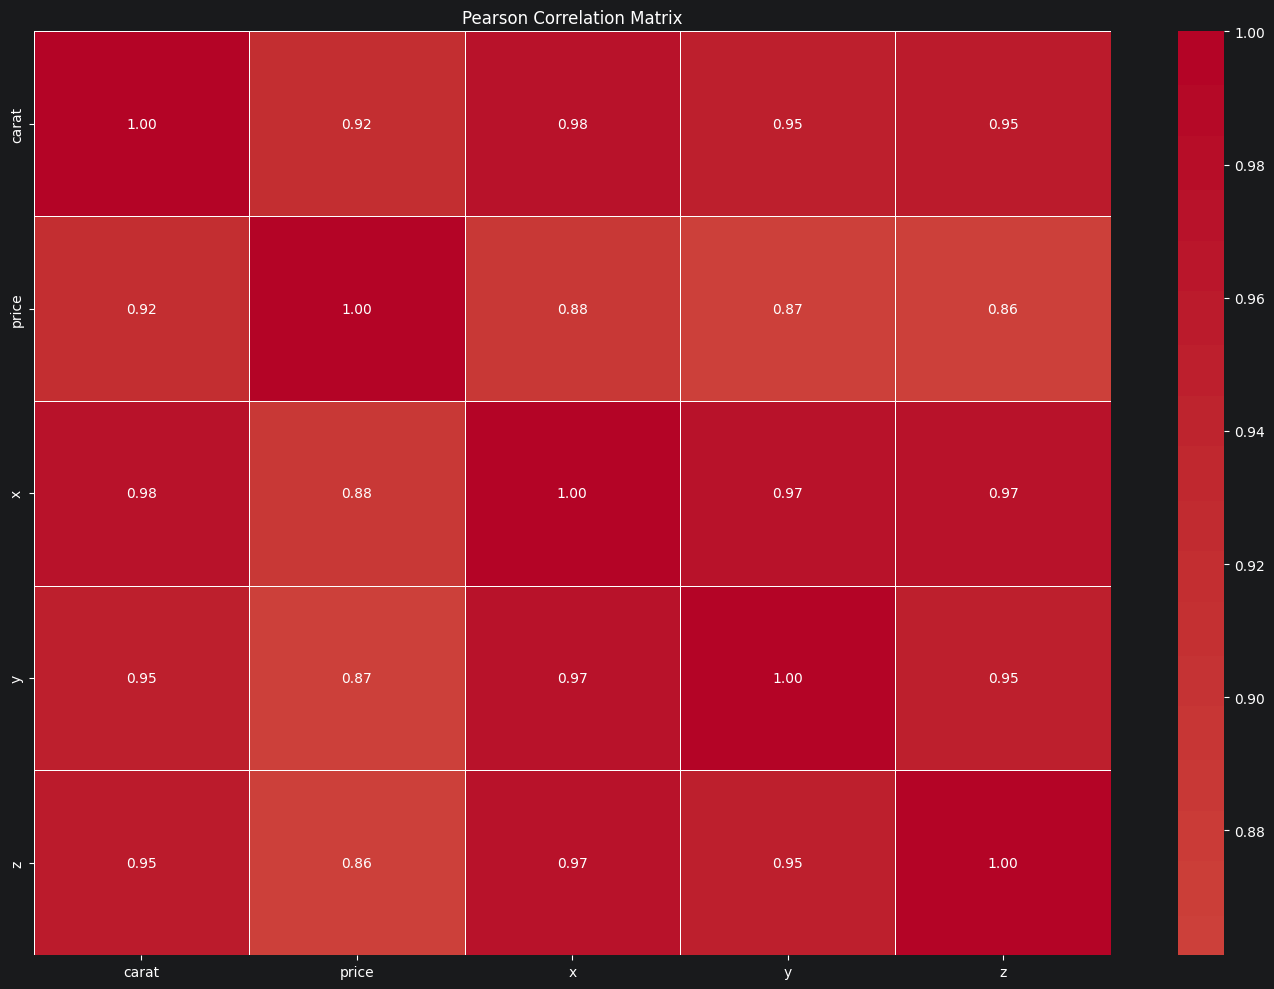

In [45]:
high_corr_cols = corr_pearson.index[corr_pearson['price'].abs() > 0.3].tolist()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_pearson.loc[high_corr_cols, high_corr_cols],
    cmap="coolwarm", center=0, annot=True, fmt=".2f", linewidths=0.5
)
plt.title("Pearson Correlation Matrix")
plt.tight_layout()
plt.show()

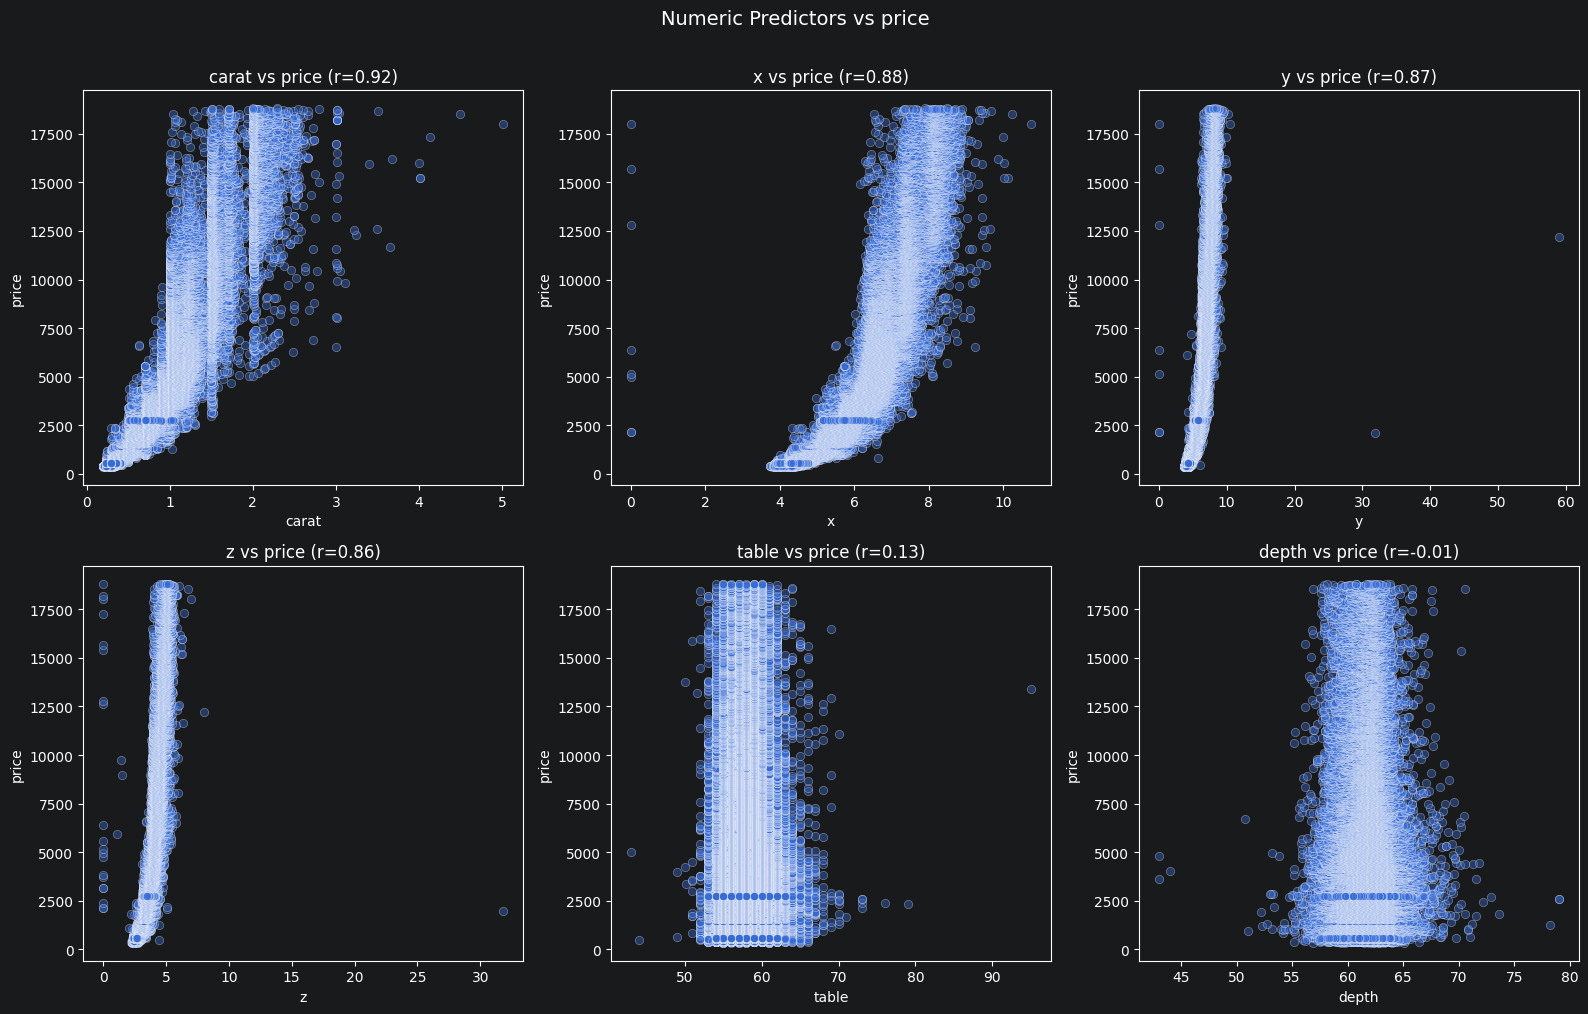

In [46]:
top_predictors = corr_target_pearson.drop('price').abs().sort_values(ascending=False).index.tolist()
n = len(top_predictors)
ncols = 3
nrows = -(-n // ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 5))
axes = axes.flatten()

for i, col in enumerate(top_predictors):
    sns.scatterplot(data=df, x=col, y='price', alpha=0.4, ax=axes[i])
    axes[i].set_title(f"{col} vs price (r={corr_target_pearson[col]:.2f})")

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeric Predictors vs price", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

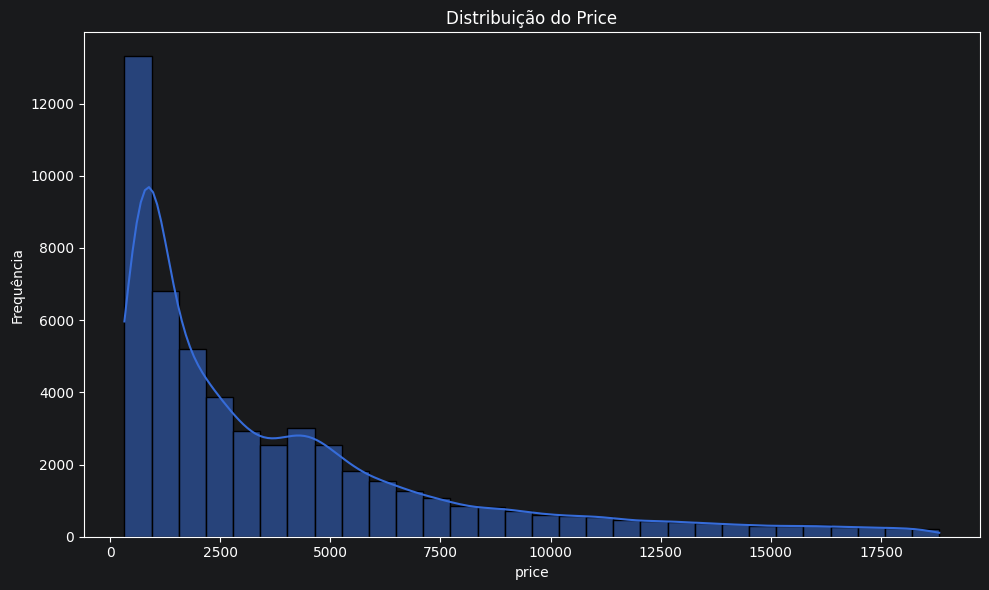

In [47]:
plt.figure(figsize=(10, 6))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribuição do Price')
plt.xlabel('price')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

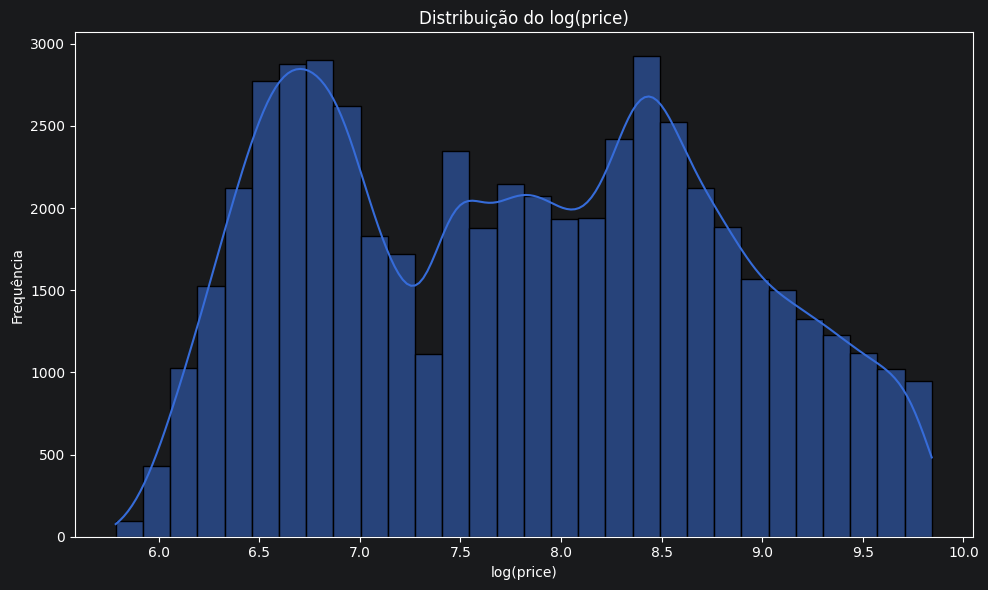

In [48]:
plt.figure(figsize=(10, 6))
sns.histplot(np.log(df['price']), bins=30, kde=True)
plt.title('Distribuição do log(price)')
plt.xlabel('log(price)')
plt.ylabel('Frequência')
plt.tight_layout()
plt.show()

In [49]:
for col in ['x', 'y', 'z']:
    n_zero = (df[col] == 0).sum()
    print(f"{col}: {n_zero} zeros")

x: 8 zeros
y: 7 zeros
z: 20 zeros


In [50]:
df_zero = df[(df['x'] == 0) | (df['y'] == 0) | (df['z'] == 0)]
display(df_zero.head(10))


,carat,cut,color,clarity,depth,table,price,x,y,z
2208,1.00,Premium,G,SI2,59.1,59.0,3142,6.55,6.48,0.0
2315,1.01,Premium,H,I1,58.1,59.0,3167,6.66,6.60,0.0
4792,1.10,Premium,G,SI2,63.0,59.0,3696,6.50,6.47,0.0
5472,1.01,Premium,F,SI2,59.2,58.0,3837,6.50,6.47,0.0
10168,1.50,Good,G,I1,64.0,61.0,4731,7.15,7.04,0.0
11183,1.07,Ideal,F,SI2,61.6,56.0,4954,0.00,6.62,0.0
11964,1.00,Very Good,H,VS2,63.3,53.0,5139,0.00,0.00,0.0
13602,1.15,Ideal,G,VS2,59.2,56.0,5564,6.88,6.83,0.0
15952,1.14,Fair,G,VS1,57.5,67.0,6381,0.00,0.00,0.0
24395,2.18,Premium,H,SI2,59.4,61.0,12631,8.49,8.45,0.0


In [51]:
print("Duplicated rows:", df.duplicated().sum())
display(df[df.duplicated(keep=False)].head(10))

Duplicated rows: 149


,carat,cut,color,clarity,depth,table,price,x,y,z
1005,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1006,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1007,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1008,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
1009,0.79,Ideal,G,SI1,62.3,57.0,2898,5.90,5.85,3.66
2025,1.52,Good,E,I1,57.3,58.0,3105,7.53,7.42,4.28
2026,1.52,Good,E,I1,57.3,58.0,3105,7.53,7.42,4.28
2183,1.00,Fair,E,SI2,67.0,53.0,3136,6.19,6.13,4.13
2184,1.00,Fair,E,SI2,67.0,53.0,3136,6.19,6.13,4.13
2820,1.00,Fair,F,SI2,65.1,55.0,3265,6.26,6.23,4.07


In [52]:
df['volume'] = df['x'] * df['y'] * df['z']
df['price_per_carat'] = df['price'] / df['carat']
display(df[['volume', 'price_per_carat']].describe())


,volume,price_per_carat
count,53943.000000,53943.000000
mean,129.848539,4008.388804
std,78.243172,2012.609949
min,0.000000,1051.162791
25%,65.136830,2478.000000
50%,114.808572,3495.774648
75%,170.841804,4949.590136
max,3840.598060,17828.846154


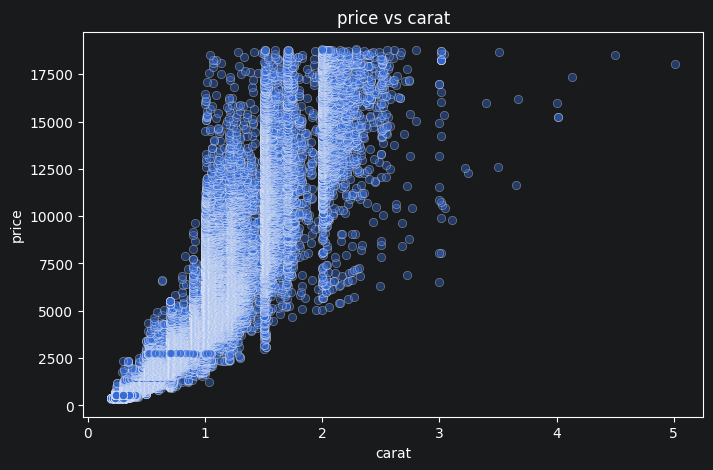

In [53]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='carat', y='price', alpha=0.4)
plt.title('price vs carat')
plt.show()


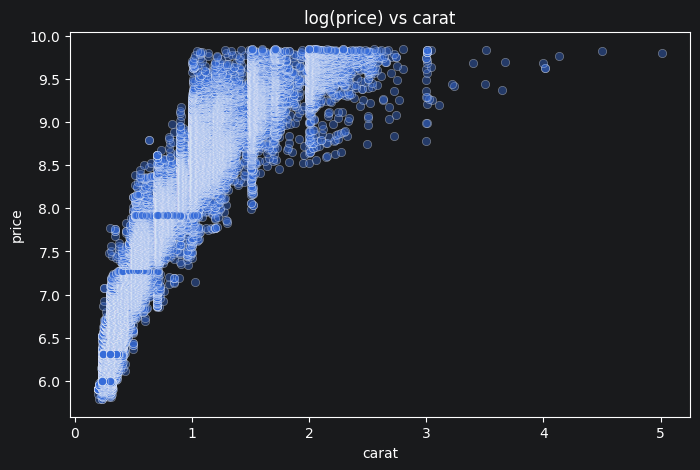

In [54]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='carat', y=np.log(df['price']), alpha=0.4)
plt.title('log(price) vs carat')
plt.show()


In [55]:
q1 = df['price'].quantile(0.25)
q3 = df['price'].quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers_price = df[(df['price'] < lower) | (df['price'] > upper)]
print("Outliers (IQR) in price:", len(outliers_price))
display(outliers_price.sort_values('price', ascending=False).head(10))

Outliers (IQR) in price: 3540


,carat,cut,color,clarity,depth,table,price,x,y,z,volume,price_per_carat
27750,2.29,Premium,I,VS2,60.8,60.0,18823,8.50,8.47,5.16,371.494200,8219.650655
27749,2.00,Very Good,G,SI1,63.5,56.0,18818,7.90,7.97,5.04,317.333520,9409.000000
27748,1.51,Ideal,G,IF,61.7,55.0,18806,7.37,7.41,4.56,249.029352,12454.304636
27747,2.07,Ideal,G,SI2,62.5,55.0,18804,8.20,8.13,5.11,340.663260,9084.057971
27746,2.00,Very Good,H,SI1,62.8,57.0,18803,7.95,8.00,5.01,318.636000,9401.500000
27745,2.29,Premium,I,SI1,61.8,59.0,18797,8.52,8.45,5.24,377.248560,8208.296943
27743,2.04,Premium,H,SI1,58.1,60.0,18795,8.37,8.28,4.84,335.429424,9213.235294
27744,2.00,Premium,I,VS1,60.8,59.0,18795,8.13,8.02,4.91,320.144766,9397.500000
27742,2.15,Ideal,G,SI2,62.6,54.0,18791,8.29,8.35,5.21,360.644015,8740.000000
27741,1.71,Premium,F,VS2,62.3,59.0,18791,7.57,7.53,4.70,267.909870,10988.888889


In [65]:
X_vif_phys = df[['x', 'y', 'z', 'depth', 'table']].dropna()
Xc_phys = sm.add_constant(X_vif_phys)
vif_phys = pd.Series(
    [variance_inflation_factor(Xc_phys.values, i) for i in range(Xc_phys.shape[1])],
    index=Xc_phys.columns
)
vif_phys

const    4083.072250
x          37.193868
y          20.433109
z          23.529001
depth       1.432490
table       1.141932
dtype: float64

In [68]:
X_cd = df[['carat', 'x', 'y', 'z']].dropna()
Xc_cd = sm.add_constant(X_cd)
y_cd = df.loc[Xc_cd.index, 'price']
model_cd = sm.OLS(y_cd, Xc_cd).fit()
influence = model_cd.get_influence()
(cooks, pvals) = influence.cooks_distance
pd.Series(cooks, index=Xc_cd.index).sort_values(ascending=False).head(10)


48411    64.161061
24068    60.196657
27416     0.391155
49190     0.220827
11183     0.180384
27631     0.175125
27430     0.109839
27131     0.098375
26000     0.095157
25999     0.090383
dtype: float64

In [67]:
corr_spearman = df.corr(method='spearman', numeric_only=True)
corr_target_spearman = corr_spearman['price'].sort_values(ascending=False)

comparison = pd.DataFrame({
    'Pearson': corr_target_pearson,
    'Spearman': corr_target_spearman
}).dropna().sort_values('Spearman', ascending=False)

comparison.head(20)

,Pearson,Spearman
price,1.000000,1.000000
x,0.884433,0.963199
carat,0.921591,0.962886
y,0.865419,0.962722
z,0.861249,0.957235
table,0.127118,0.171781
depth,-0.010630,0.010009


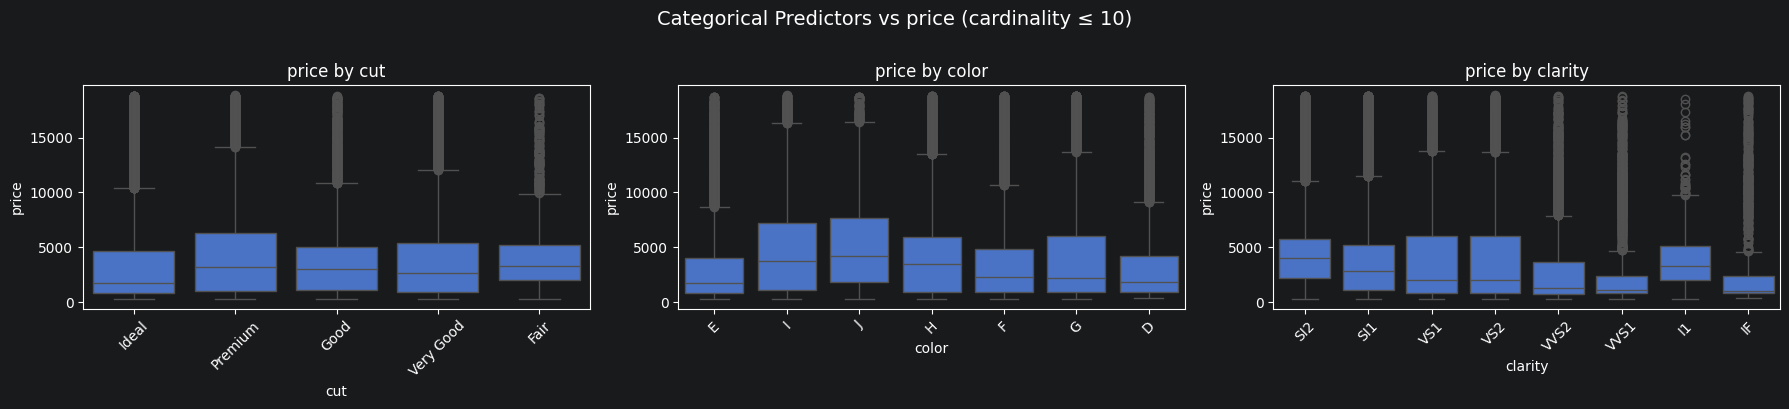

In [59]:
cat_cols_low_card = categorical_report[categorical_report['cardinality'] <= 10]['variable'].tolist()
n = len(cat_cols_low_card)
ncols = 3

if n > 0:
    nrows = -(-n // ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(18, nrows * 4))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols_low_card):
        sns.boxplot(data=df, x=col, y='price', ax=axes[i])
        axes[i].set_title(f"price by {col}")
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Categorical Predictors vs price (cardinality ≤ 10)", fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

In [60]:
vif_candidates = corr_target_pearson.drop('price').abs().sort_values(ascending=False).index.tolist()

In [61]:
X_vif = df[vif_candidates].dropna()
X_vif = sm.add_constant(X_vif)

In [62]:
vif_df = pd.DataFrame({
    'variable': X_vif.columns,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
})

vif_df[vif_df['variable'] != 'const'].sort_values('VIF', ascending=False)

,variable,VIF
2,x,56.187020
4,z,23.530057
1,carat,21.602141
3,y,20.454259
6,depth,1.496646
5,table,1.143233


In [63]:
def cramers_v(x, y):
    table = pd.crosstab(x, y)
    n = table.sum().sum()
    k = min(table.shape)
    if k <= 1:
        return np.nan
    chi2, _, _, _ = chi2_contingency(table)
    return np.sqrt(chi2 / (n * (k - 1)))


cat_cols_for_cramers = categorical_report[categorical_report['cardinality'] <= 15]['variable'].tolist()

pairs = []
for i, col1 in enumerate(cat_cols_for_cramers):
    for col2 in cat_cols_for_cramers[i+1:]:
        value = cramers_v(df[col1], df[col2])
        if not np.isnan(value):
            pairs.append({'var1': col1, 'var2': col2, 'cramers_v': round(value, 3)})

pd.DataFrame(pairs).sort_values('cramers_v', ascending=False).head(20)

,var1,var2,cramers_v
1,cut,clarity,0.143
2,color,clarity,0.080
0,cut,color,0.038
